In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pathlib

import dotenv
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn import metrics

import highres_ta as ta

BASE = pathlib.Path(dotenv.find_dotenv("pyproject.toml")).parent


In [3]:
COORD_COLUMNS = [
    "expocode",
    "time",
    "lat",
    "lon",
    "depth",
]
TARGET_NAME = "talk"
FEATURE_NAMES = [
    "salinity",
    "temperature",
    "ssh_adt",
    "nitrate",
    "phosphate",
    "silicate",
    "bottomdepth",
]
QC_COLS = ["talkqc", "talkf"]
REQUIRED_COLUMNS = list(set(COORD_COLUMNS + FEATURE_NAMES + [TARGET_NAME] + QC_COLS))
NONAN_SUBSET = [TARGET_NAME, "salinity", "temperature", "nitrate", "ssh_adt"]
LINEAR_FEATURES = ["salinity", "temperature"]
FEATURE_NAMES += [
    "ncoord_x",
    "ncoord_y",
    "ncoord_z",
    "dayofyear_sin",
    "dayofyear_cos",
]


In [4]:
data = (
    ta
    .load_data()[REQUIRED_COLUMNS]
    .set_index(COORD_COLUMNS, drop=False)
    .pipe(ta.drop_extreme_salinities, min=20, max=40)
    .pipe(
        ta.add_talk_adjustment,
        fname=str(BASE / "data" / "glodapv2_adjustments_last_updated_on_2026_07_09.csv"),
    )
    .pipe(ta.drop_bad_quality_talk)
    .dropna(subset=NONAN_SUBSET)
    .drop_duplicates(subset=COORD_COLUMNS, keep="first")
    .select_dtypes(include=[np.number])
    .pipe(ta.add_cyclical_dayofyear)
    .pipe(ta.add_spherical_coords)
    .loc[:, FEATURE_NAMES + [TARGET_NAME]]
)

data.columns


2026-09-11 12:02:46.766 | DEBUG    | highres_ta.dataio:load_data:18 - Loading 40 .pq files from ../data/training
2026-09-11 12:02:48.233 | DEBUG    | highres_ta.target_filtering:drop_bad_quality_talk:49 - TA values with large adjustments (<= 6.0 mol/kg): 2365
2026-09-11 12:02:48.234 | DEBUG    | highres_ta.target_filtering:drop_bad_quality_talk:52 - TA values without good flags (!= 2): 3046
2026-09-11 12:02:48.234 | INFO     | highres_ta.target_filtering:drop_bad_quality_talk:53 - Number of rows filtered due to large adjustments and bad flags: 5319 of 41534 (13%)


Index(['salinity', 'temperature', 'ssh_adt', 'nitrate', 'phosphate',
       'silicate', 'bottomdepth', 'ncoord_x', 'ncoord_y', 'ncoord_z',
       'dayofyear_sin', 'dayofyear_cos', 'talk'],
      dtype='str')

In [52]:
subsets = []
for r in range(25):
    train_idx, test_idx = ta.make_train_test_folds(data, n_splits=3, random_state=r)[1]
    subsets += data.iloc[train_idx].index,

2026-09-11 12:18:06.154 | DEBUG    | highres_ta.train_test_split:make_salinity_bins:48 - Using the following bin edges for salinity: [20.1909  32.8038  34.05706 34.819   35.535   39.231  ]
2026-09-11 12:18:06.159 | DEBUG    | highres_ta.train_test_split:stratified_group_folds:96 - Making train-test splits stratified by salinity_bin and grouped by expocode
2026-09-11 12:18:06.256 | DEBUG    | highres_ta.train_test_split:make_salinity_bins:48 - Using the following bin edges for salinity: [20.1909  32.8038  34.05706 34.819   35.535   39.231  ]
2026-09-11 12:18:06.261 | DEBUG    | highres_ta.train_test_split:stratified_group_folds:96 - Making train-test splits stratified by salinity_bin and grouped by expocode
2026-09-11 12:18:06.357 | DEBUG    | highres_ta.train_test_split:make_salinity_bins:48 - Using the following bin edges for salinity: [20.1909  32.8038  34.05706 34.819   35.535   39.231  ]
2026-09-11 12:18:06.362 | DEBUG    | highres_ta.train_test_split:stratified_group_folds:96 - Ma

In [57]:
list(range(35))

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34]

In [53]:
n = len(subsets)
counts = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        test_size = len(subsets[i])
        counts[i, j] = subsets[i].isin(subsets[j]).sum()

In [54]:
import seaborn as sns

<Axes: >

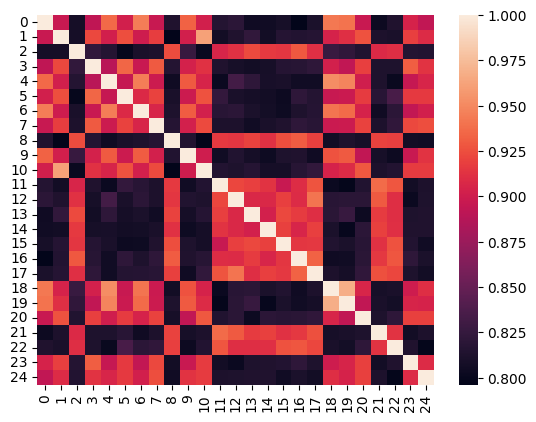

In [55]:
sns.heatmap(counts/test_size)